In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures

In [105]:
def sample_gaussian_chain(n_samples, 
                          mu1=0, sigma1=1, 
                          a=2., b=0.0, sigma2=0.8, 
                          c=3., d=0.0, sigma3=0.5):
    """
    Samples from a Gaussian chain: x1 -> x2 -> x3.
    
    Parameters:
        n_samples: int
            Number of samples to generate
        mu1, sigma1: float
            Mean and std for x1
        a, b, sigma2: float
            Parameters for x2 | x1 ~ N(a*x1 + b, sigma2^2)
        c, d, sigma3: float
            Parameters for x3 | x2 ~ N(c*x2 + d, sigma3^2)
    
    Returns:
        x1_samples, x2_samples, x3_samples: np.ndarray
            Arrays of shape (n_samples,)
    """
    x1_samples = np.random.normal(mu1, sigma1, n_samples)
    x2_samples = np.random.normal(a * x1_samples + b, sigma2)
    x3_samples = np.random.normal(c * x2_samples + d, sigma3)
    
    return x1_samples, x2_samples, x3_samples

In [106]:
x1, x2, x3 = sample_gaussian_chain(10_000)
X = np.column_stack([x1, x2, x3])

In [112]:
V = PolynomialFeatures(degree=4).fit_transform(X)
M = V.T @ V / len(V)

<Axes: >

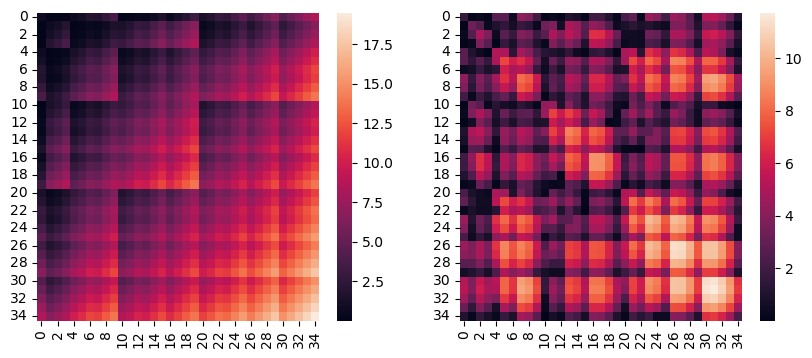

In [113]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(np.log1p(np.abs(M)), ax=ax[0])
sns.heatmap(np.log1p(np.abs(np.linalg.inv(M))), ax=ax[1])

In [103]:
np.mean(np.abs(M).flatten() < 1e-3), np.mean(np.abs(np.linalg.inv(M).flatten()) < 1e-3)

(np.float64(0.0), np.float64(0.005))